In [32]:
!pip install torchmetrics
!pip install torcheval

## Unsupervised learning part

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from pathlib import Path

In [34]:
def load_csv(file_path: str):
  if not file_path.is_file():
    print(f"Error: File '{file_path}' not found")
    return None

  try:
    df = pd.read_csv(file_path, encoding='utf-8')
    return df

  except pd.errors.EmptyDataError:
        print("Error: The CSV file is empty.")
  except pd.errors.ParserError:
      print("Error: The CSV file is malformed.")
  except Exception as e:
      print(f"Unexpected error: {e}")

  return None

In [35]:
path = Path("/content/books.csv")
df = load_csv(path)

In [36]:
df["price"] = df["price"].str.replace("£", "").astype(float)
rating_map = {"One":1, "Two":2, "Three":3, "Four":4, "Five":5}
df["rating_num"] = df["rating"].map(rating_map)
X = df[["price", "rating_num"]]

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
inertia = []
silhouette = []
db_index = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))
    db_index.append(davies_bouldin_score(X_scaled, labels))

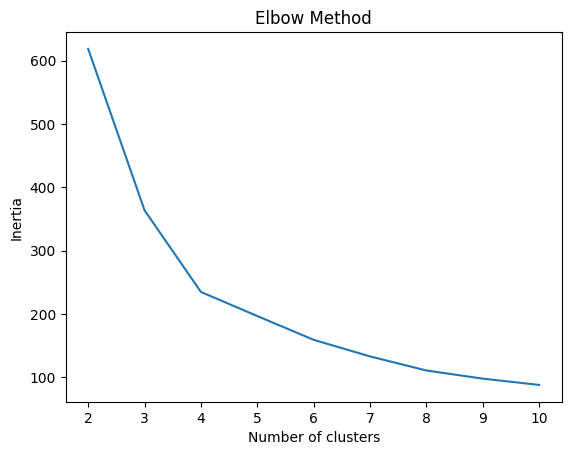

In [39]:
plt.plot(K, inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

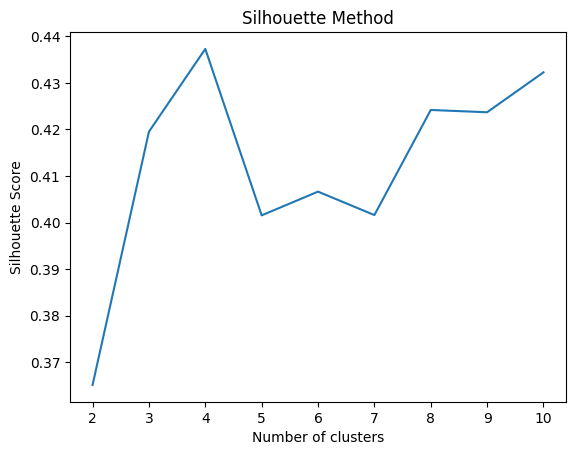

In [40]:
plt.plot(K, silhouette)
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

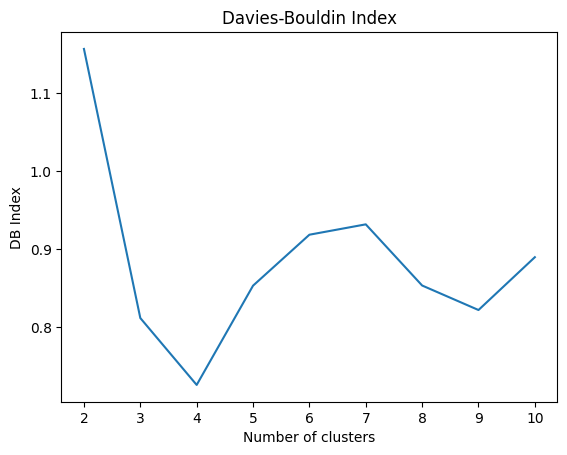

In [41]:
plt.plot(K, db_index)
plt.xlabel("Number of clusters")
plt.ylabel("DB Index")
plt.title("Davies-Bouldin Index")
plt.show()

In [42]:
import numpy as np
k = K[np.argmax(silhouette)]
k

4

In [43]:
genre_map = {
    0: "Sci-fi",
    1: "Detective",
    2: "Horror",
    3: "Comedy"
}

In [44]:
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

X_res = X
X_res["Genre Labels"] = df["cluster"].map(genre_map)
X_res["Genre"] = df["cluster"]

X_res.to_csv("books_clustered.csv", index=False)

/tmp/ipython-input-1973937144.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res["Genre Labels"] = df["cluster"].map(genre_map)
/tmp/ipython-input-1973937144.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_res["Genre"] = df["cluster"]


In [45]:
df["cluster"].map(genre_map)

,cluster
0,Horror
1,Horror
2,Horror
3,Horror
4,Horror
...,...
496,Sci-fi
497,Detective
498,Sci-fi
499,Sci-fi


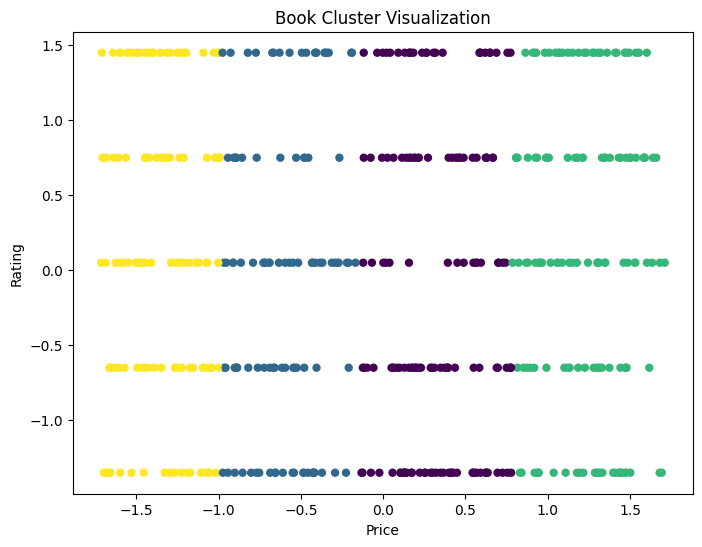

In [46]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df["cluster"], s=25)
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Book Cluster Visualization")
plt.show()

## MLP part

In [47]:
import torch
from torch import nn
from torch.utils.data import random_split, Dataset, DataLoader

from tqdm.auto import tqdm
from pathlib import Path
import pandas as pd

In [48]:
BATCH_SIZE = 16

In [49]:
path = Path("/content/books_clustered.csv")
books = load_csv(path)

In [50]:
class BookDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [51]:
class MLP(nn.Module):
  def __init__(self, in_features: int, hidden_size: int, out_features: int):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Linear(in_features=in_features, out_features=hidden_size),
        nn.ReLU(),
        torch.nn.Dropout(0.1),
        nn.Linear(in_features=hidden_size, out_features=hidden_size),
        nn.ReLU(),
        nn.Linear(in_features=hidden_size, out_features=out_features)
    )

  def forward(self, x):
    return self.mlp(x)

In [52]:
def train_step(model: torch.nn.Module,
               train_dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optim: torch.optim.Optimizer,
               device: torch.device):

  model.train()
  train_loss, train_acc = 0, 0

  for batch, (X, y) in enumerate(train_dataloader):
    X, y = X.to(device), y.to(device)

    # forward pass
    logits = model(X)
    loss = loss_fn(logits, y)

    # backpropagation
    optim.zero_grad()
    loss.backward()

    # step
    optim.step()

    train_loss += loss.item()
    preds = logits.argmax(dim=1)
    train_acc += ((preds == y).sum() / len(logits)).item()

  train_loss /= len(train_dataloader)
  train_acc /= len(train_dataloader)

  return train_loss, train_acc

def test_step(model: torch.nn.Module,
               test_dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               device: torch.device):

  model.eval()
  test_loss, test_acc = 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
      X, y = X.to(device), y.to(device)

      logits = model(X)
      loss = loss_fn(logits, y)
      test_loss += loss.item()
      preds = logits.argmax(dim=1)
      test_acc += ((preds == y).sum() / len(logits)).item()

    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optim: torch.optim.Optimizer,
          epochs: int,
          device: torch.device):

  results = {
      "train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": []
  }
  model.to(device)

  for epoch in tqdm(range(epochs), desc="Training the model..."):
    train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optim, device)
    test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

    if (epoch + 1) % 10 == 0:
      print(f"Epoch: {epoch + 1}: Train loss: {train_loss:.4f} | train_acc: {train_acc:.2f} | Test loss: {test_loss:.2f} | Test acc: {test_acc:.4f}")

  return results



In [53]:

X = books[["price", "rating_num"]].to_numpy()
y = books["Genre"].to_numpy()
class_names = list(books["Genre Labels"].unique())
dataset = BookDataset(X, y)

In [54]:
class_names

['Horror', 'Detective', 'Sci-fi', 'Comedy']

In [55]:
length = len(books)
train_length = int( 0.8 * length)
test_length = length - train_length


In [63]:
length - train_length

101

In [56]:
generator = torch.Generator().manual_seed(42)

In [57]:
train_data, test_data = random_split(dataset,
                                    [train_length, test_length],
                                     generator)
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, generator=generator)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, generator=generator)

In [61]:
device = "cuda" if torch.cuda.is_available() else "cpu"
epochs = 70
hidden_units = 20
lr = 0.1e-2

model = MLP(2, hidden_units, len(class_names))
loss_fn = torch.nn.CrossEntropyLoss()
optim = torch.optim.Adam(params=model.parameters(), lr=lr, weight_decay=0.1e-3)


results = train(model, train_dataloader, test_dataloader, loss_fn, optim, epochs, device)

Training the model...:   0%|          | 0/70 [00:00<?, ?it/s]

Epoch: 10: Train loss: 1.1196 | train_acc: 0.41 | Test loss: 1.04 | Test acc: 0.5232
Epoch: 20: Train loss: 0.9068 | train_acc: 0.57 | Test loss: 0.86 | Test acc: 0.5589
Epoch: 30: Train loss: 0.7275 | train_acc: 0.67 | Test loss: 0.68 | Test acc: 0.6857
Epoch: 40: Train loss: 0.5633 | train_acc: 0.81 | Test loss: 0.56 | Test acc: 0.7661
Epoch: 50: Train loss: 0.5116 | train_acc: 0.80 | Test loss: 0.44 | Test acc: 0.8929
Epoch: 60: Train loss: 0.4308 | train_acc: 0.86 | Test loss: 0.38 | Test acc: 0.9196
Epoch: 70: Train loss: 0.3511 | train_acc: 0.89 | Test loss: 0.32 | Test acc: 0.9464


In [80]:
from torchmetrics import Accuracy
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, ConfusionMatrix
from torcheval.metrics.functional import multiclass_f1_score

model.eval()

all_preds = []
all_labels = []
num_classes = len(class_names)

with torch.inference_mode():
    for batch, (X, y) in enumerate(test_dataloader):
        model.to(device)
        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds)
        all_labels.extend(y)
    all_preds = torch.tensor(all_preds, device=device)
    all_labels = torch.tensor(all_labels, device=device)

accuracy = Accuracy(task="multiclass", num_classes=num_classes).to(device)
precision = MulticlassPrecision(num_classes=num_classes, average="macro").to(device)
recall = MulticlassRecall(num_classes=num_classes, average='macro').to(device)
f1 = multiclass_f1_score(preds, y, num_classes=num_classes, average="macro")
acc = accuracy(preds, y).item()
prec = precision(preds, y)
re = recall(preds, y)

print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {re:.4f} | f1 score: {f1:.4f}")

Accuracy: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | f1 score: 1.0000


Confusion Matrix (Tensor):
 tensor([[24,  0,  4,  0],
        [ 0, 16,  0,  2],
        [ 0,  0, 33,  0],
        [ 0,  0,  0, 22]], device='cuda:0')


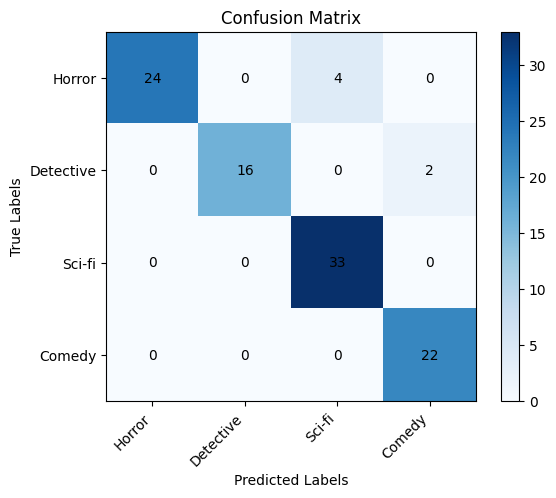

In [81]:
confmat = ConfusionMatrix(task="multiclass", num_classes=num_classes).to(device)

cm = confmat(all_preds, all_labels)

print("Confusion Matrix (Tensor):\n", cm)

fig, ax = plt.subplots()
im = ax.imshow(cm.cpu().numpy(), cmap="Blues")

ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_title("Confusion Matrix")
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

plt.colorbar(im)
plt.show()